In [1]:
import json

# Bước 1: Đọc file JSON gốc
input_file = '/kaggle/input/crawl-facebook/parsed_friends.json'

with open(input_file, 'r', encoding='utf-8') as file:
    data = json.load(file)

print("Tổng số friends:", len(data['friends']))
print(json.dumps(data['friends'][0], ensure_ascii=False, indent=2)[:20] + "...")  # In ngắn gọn

Tổng số friends: 24
{
  "name": "Hà Vi",...


# Xử lý lọc

In [2]:
# Bước 2: Xử lý từng friend
from_keywords = ["Đã ghé thăm", "Thêm bạn bè", "Theo dõi", "Đã chia sẻ với Công khai", "Phản hồi"]  # Các từ khóa cần loại bỏ

for friend in data['friends']:
    # Lọc mutual_names: giữ lại item không chứa bất kỳ từ khóa nào
    filtered_names = [
        name for name in friend['mutual_names']
        if not any(keyword in name for keyword in from_keywords)
    ]
    
    # Cập nhật mảng và count
    friend['mutual_names'] = filtered_names
    friend['mutual_count'] = len(filtered_names)

print("Tổng mutual_count sau lọc:", sum(friend['mutual_count'] for friend in data['friends']))

Tổng mutual_count sau lọc: 342


In [3]:
# Bước 3: Ghi ra file JSON mới
output_file = '/kaggle/working/filtered_friends.json'  # Lưu ở working dir trên Kaggle
with open(output_file, 'w', encoding='utf-8') as file:
    json.dump(data, file, ensure_ascii=False, indent=4)

print(f"Xử lý hoàn tất! File mới: {output_file}")

# In ví dụ để kiểm tra
found = False
for friend in data['friends']:
    if friend['name'] == 'Dương Vân':
        print(json.dumps(friend, ensure_ascii=False, indent=2))
        found = True
        break
if not found:
    print("Không tìm thấy 'Dương Vân', in friend đầu tiên:")
    print(json.dumps(data['friends'][0], ensure_ascii=False, indent=2))

Xử lý hoàn tất! File mới: /kaggle/working/filtered_friends.json
{
  "name": "Dương Vân",
  "mutual_names": [
    "Kelly Thao Nguyen",
    "Phan Hường"
  ],
  "mutual_count": 2,
  "profile_url": "https://www.facebook.com/duong.van.988450"
}


# Xây dựng mạng của bản thân

In [4]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

In [5]:
input_file = '/kaggle/working/filtered_friends.json'
print("Tổng số friends:", len(data['friends']))

Tổng số friends: 24


In [6]:
all_nodes = set()
friends_list = []  # List các friend names để làm nguồn edges

for friend in data['friends']:
    friend_name = friend['name']
    if friend_name == 'Bạn' or friend_name == 'bạn':  # Skip bản thân nếu có
        continue
    friends_list.append(friend_name)
    all_nodes.add(friend_name)
    
    for mutual in friend['mutual_names']:
        all_nodes.add(mutual.strip())  # Strip để sạch

nodes_list = list(all_nodes)
print(f"Tổng unique nodes (bạn bè + bạn chung): {len(nodes_list)}")

Tổng unique nodes (bạn bè + bạn chung): 132


# Trích xuất danh sách bạn bè và xây mạng đồng bản thân 

In [7]:
# Xây dựng Directed Graph (có hướng: từ friend -> mutual)
G = nx.DiGraph()  # Directed Graph

# Thêm nodes
G.add_nodes_from(nodes_list)

# Thêm directed edges: Từ mỗi friend đến mutuals của họ (theo dõi / được theo dõi)
edges_added = 0
for friend in data['friends']:
    friend_name = friend['name']
    if friend_name == 'Bạn' or friend_name == 'bạn':
        continue
    for mutual in friend['mutual_names']:
        mutual = mutual.strip()
        if friend_name != mutual:  # Tránh self-loop
            G.add_edge(friend_name, mutual)  # Hướng: friend theo dõi mutual
            # edges_added += 1

print(f"Graph xây dựng: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph xây dựng: 132 nodes, 342 edges


# Phân tích tổng quan

## Số nút/cạnh, Đường kính, Bán kính

In [8]:
# Số lượng nút và cạnh
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Số nút: {num_nodes}")
print(f"Số cạnh: {num_edges}")

# Đường kính và bán kính (chuyển sang undirected để tính, vì DiGraph có thể không connected)
G_undir = G.to_undirected()
if nx.is_connected(G_undir):
    diameter = nx.diameter(G_undir)
    radius = nx.radius(G_undir)
else:
    diameter = "Graph không connected (không tính được)"
    radius = "Graph không connected"
print(f"Đường kính: {diameter}")
print(f"Bán kính: {radius}")

Số nút: 132
Số cạnh: 342
Đường kính: Graph không connected (không tính được)
Bán kính: Graph không connected


## Hệ số phân cụm, Histogram

In [9]:
# Hệ số phân cụm (dùng undirected graph)
clustering_coeffs = nx.clustering(G_undir)  # Dùng undirected
global_clustering = nx.average_clustering(G_undir)
local_clustering_mean = np.mean(list(clustering_coeffs.values()))

print(f"Hệ số phân cụm toàn cục: {global_clustering:.4f}")
print(f"Hệ số phân cụm cục bộ trung bình: {local_clustering_mean:.4f}")

Hệ số phân cụm toàn cục: 0.1335
Hệ số phân cụm cục bộ trung bình: 0.1335


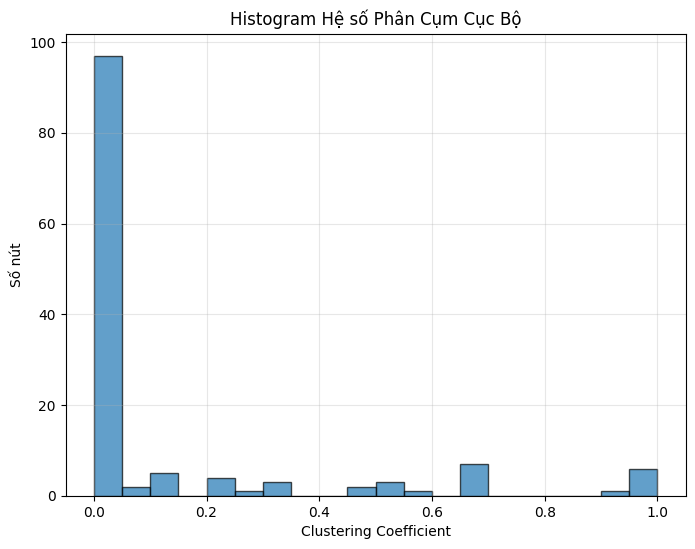

Clustering range: 0.0000 - 1.0000


In [10]:
# Histogram hệ số phân cụm cục bộ
plt.figure(figsize=(8, 6))
plt.hist(list(clustering_coeffs.values()), bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram Hệ số Phân Cụm Cục Bộ')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Số nút')
plt.grid(True, alpha=0.3)
plt.savefig('part2_clustering_hist.png')  # Lưu để download
plt.show()

# Giá trị min/max clustering để báo cáo
print(f"Clustering range: {min(clustering_coeffs.values()):.4f} - {max(clustering_coeffs.values()):.4f}")

In [11]:
# Tính độ dài đường đi trung bình
if nx.is_connected(G_undir):
    avg_path_length = nx.average_shortest_path_length(G_undir)
    print(f"Độ dài đường đi trung bình: {avg_path_length:.4f}")
else:
    print("Graph không connected, bỏ qua đường đi.")
    avg_path_length = "N/A"

Graph không connected, bỏ qua đường đi.


In [12]:
# Histogram đường đi (chỉ nếu connected)
if nx.is_connected(G_undir):
    sample_node = list(G_undir.nodes())[0]  # Node mẫu đầu tiên
    paths = dict(nx.single_source_shortest_path_length(G_undir, sample_node))
    path_lengths = list(paths.values())
    
    plt.figure(figsize=(8, 6))
    plt.hist(path_lengths, bins=20, edgecolor='black', alpha=0.7)
    plt.title(f'Histogram Độ Dài Đường Đi (từ node: {sample_node})')
    plt.xlabel('Độ dài đường đi')
    plt.ylabel('Số nút')
    plt.grid(True, alpha=0.3)
    plt.savefig('part2_path_hist.png')  # Lưu để download
    plt.show()
    
    # Output mẫu: Max path length
    print(f"Max đường đi từ node mẫu: {max(path_lengths)}")
else:
    print("Bỏ qua histogram vì graph không connected.")

Bỏ qua histogram vì graph không connected.


## Phân phối bậc, Hồi quy, Bố cục mạng

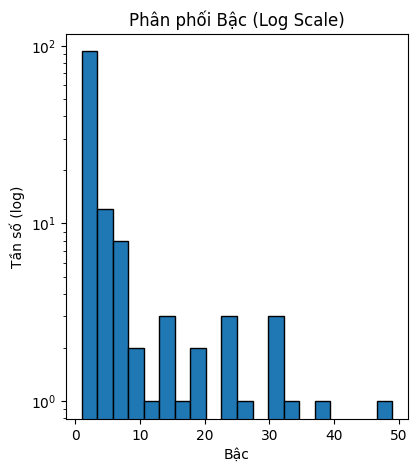

In [13]:
# Phân phối bậc (degree distribution)
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
degrees = [d for n, d in G.degree()]  # Tổng degree (undirected view)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(degrees, bins=20, log=True, edgecolor='black')
plt.title('Phân phối Bậc (Log Scale)')
plt.xlabel('Bậc')
plt.ylabel('Tần số (log)')
plt.show()

Hồi quy log-log: Slope = -0.9458, R² = 0.7086


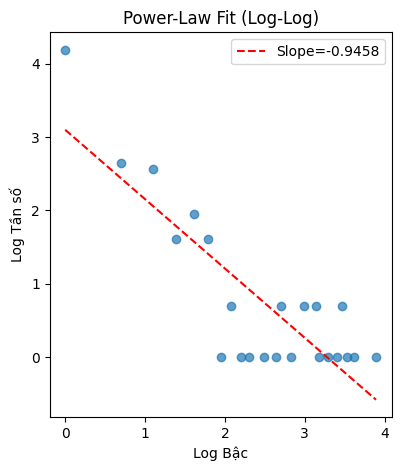

In [14]:
# Mô hình đánh giá: Hồi quy tuyến tính log-log (power-law fit) - PHIÊN BẢN ĐƠN GIẢN (BỎ KIỂM TRA)
unique_deg = sorted(set(degrees))  # Unique degrees
freq = [degrees.count(d) for d in unique_deg]  # Tần số tương ứng

log_deg = np.log(unique_deg)
log_freq = np.log(np.array(freq))  # Chuyển freq thành array trước log

# Fit trực tiếp (giả sử data OK)
slope, intercept, r_value, p_value, std_err = linregress(log_deg, log_freq)
print(f"Hồi quy log-log: Slope = {slope:.4f}, R² = {r_value**2:.4f}")

# Plot scatter + fit line
plt.figure(figsize=(15, 5))
plt.subplot(1,3,2)
plt.scatter(log_deg, log_freq, alpha=0.7)
plt.plot(log_deg, slope * log_deg + intercept, 'r--', label=f'Slope={slope:.4f}')
plt.title('Power-Law Fit (Log-Log)')
plt.xlabel('Log Bậc')
plt.ylabel('Log Tần số')
plt.legend()
plt.show()

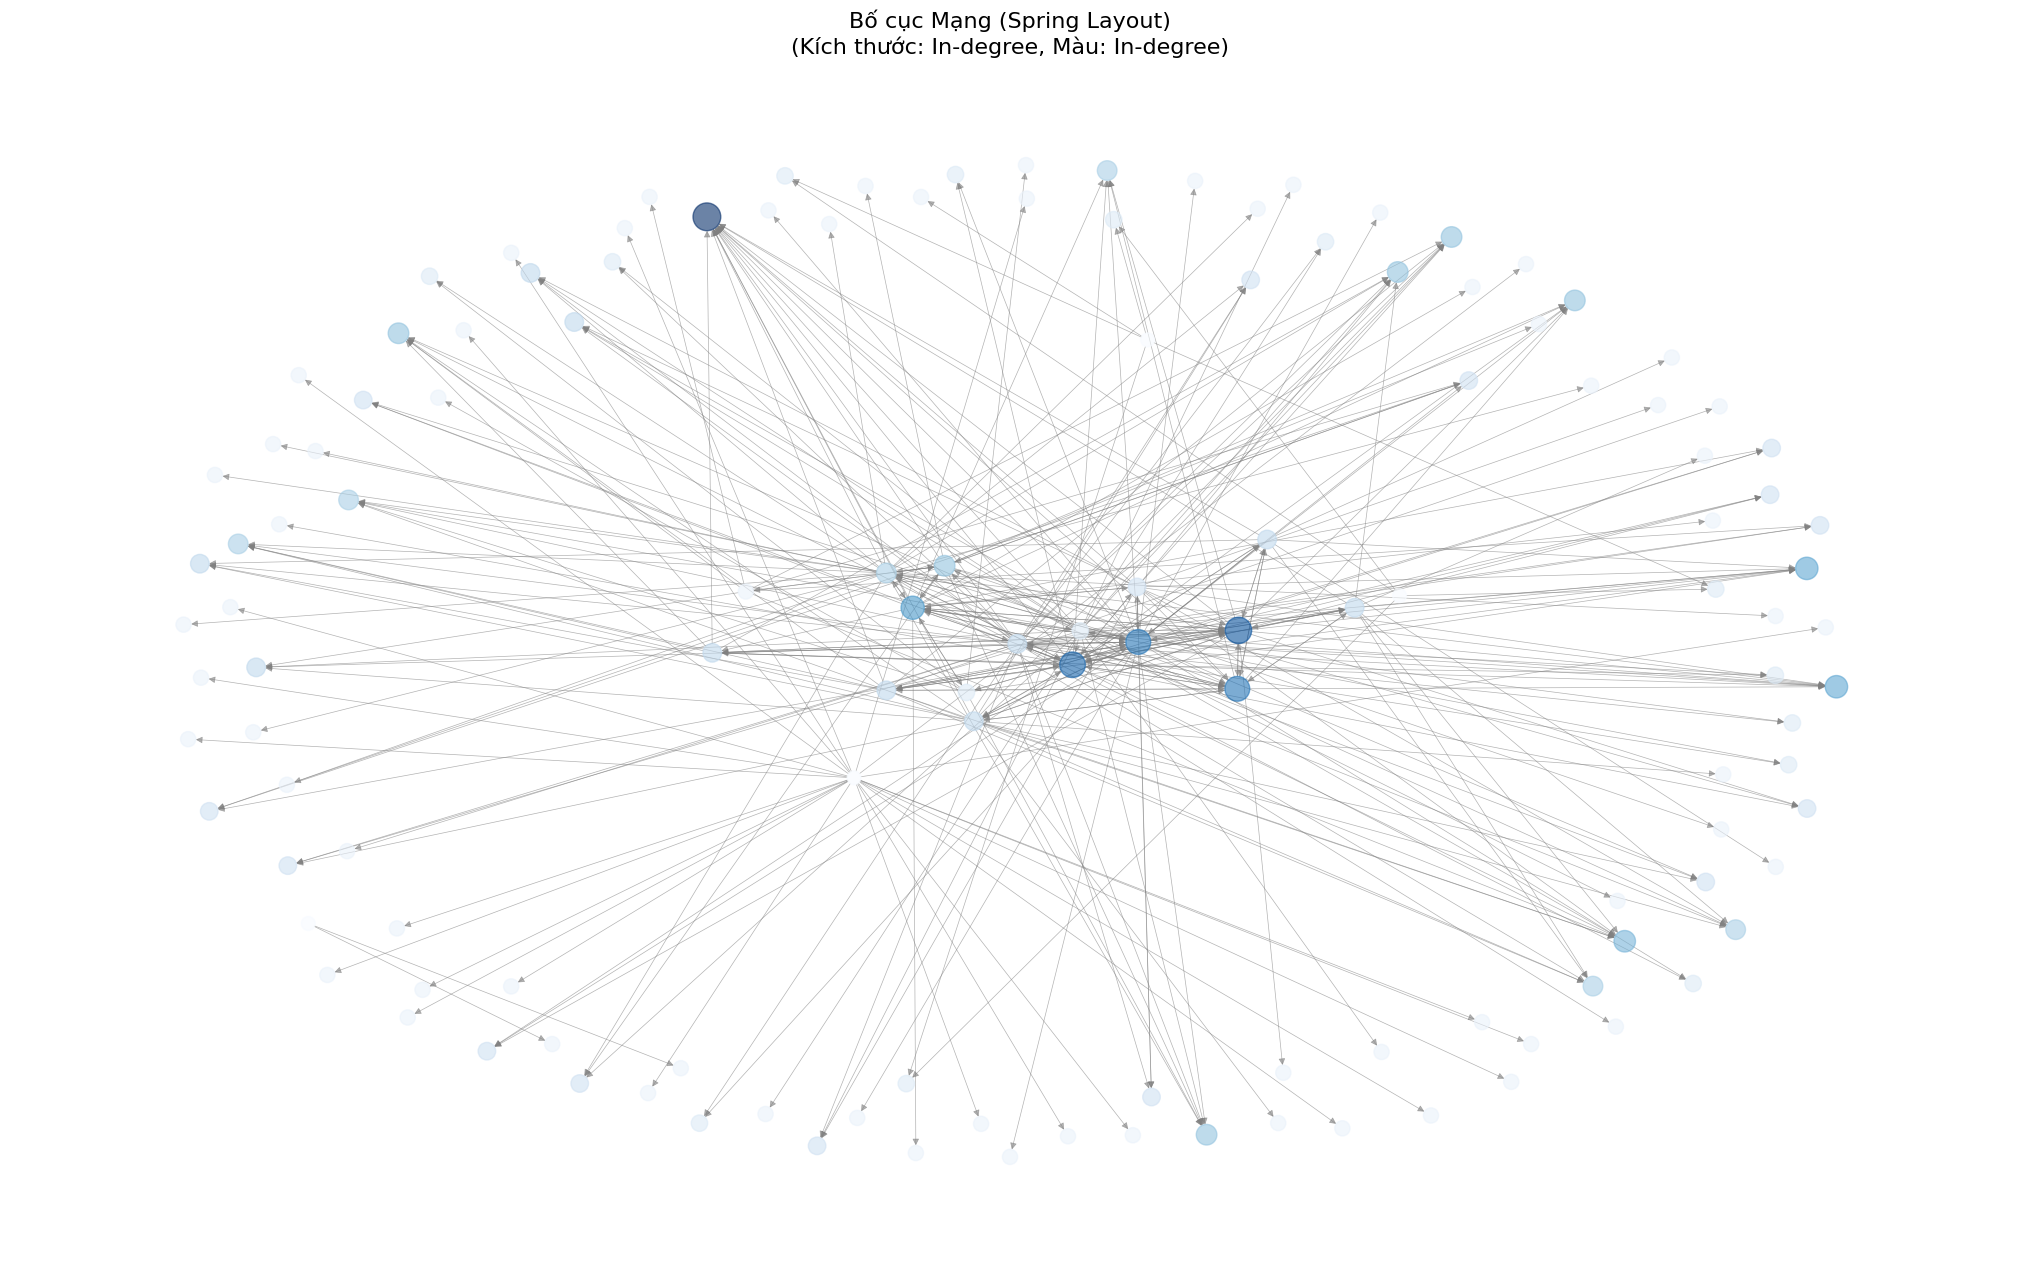

Unique degrees: 23, Freq sample: [66, 14, 13, 5, 7]...


In [15]:
# Bố cục mạng (spring layout, kích thước node ~ degree, màu ~ in-degree)
plt.figure(figsize=(20, 12))
pos = nx.spring_layout(G, k=1, iterations=50)
node_sizes = [G.in_degree(n) * 20 + 100 for n in G.nodes()]  # Scale size
node_colors = [G.in_degree(n) for n in G.nodes()]  # Màu theo in-degree

nx.draw(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.Blues, 
        arrows=True, alpha=0.6, edge_color='gray', width=0.5)
plt.title('Bố cục Mạng (Spring Layout)\n(Kích thước: In-degree, Màu: In-degree)', fontsize=16)
plt.show()

# Debug info (in ra để kiểm tra)
print(f"Unique degrees: {len(unique_deg)}, Freq sample: {freq[:5]}...")

# Phân tích cấu trúc mạng

In [16]:
# Tính các độ trung tâm
degree_cent = nx.degree_centrality(G)
closeness_cent = nx.closeness_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)

pagerank = nx.pagerank(G)
hits_h, hits_a = nx.hits(G)

# Top 5 nút trung tâm (mô tả: nút có giá trị cao là "trung tâm")
print("Top 5 nút theo Degree Centrality:")
top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_degree:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nút theo Closeness Centrality:")
top_closeness = sorted(closeness_cent.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_closeness:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nút theo Betweenness Centrality:")
top_between = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_between:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nút theo Eigenvector Centrality:")
top_eigen = sorted(eigenvector_cent.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_eigen:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nút theo PageRank:")
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_pr:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nút theo HITS (Hubs):")
top_hits_h = sorted(hits_h.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_hits_h:
    print(f"  {node}: {score:.4f}")


Top 5 nút theo Degree Centrality:
  Đinh Phạm Cẩm Ly: 0.3740
  Ngọc My: 0.2824
  Bảoo Bảoo: 0.2595
  Thùy Dương: 0.2443
  Nhật Minhh: 0.2443

Top 5 nút theo Closeness Centrality:
  Ngoc Han: 0.1178
  Ngọc Hân: 0.0959
  Bảoo Bảoo: 0.0919
  Vy Vy: 0.0882
  Đinh Phạm Cẩm Ly: 0.0882

Top 5 nút theo Betweenness Centrality:
  Đinh Phạm Cẩm Ly: 0.0263
  Nhật Minhh: 0.0185
  Vy Vy: 0.0172
  Phan Hường: 0.0169
  Bảoo Bảoo: 0.0107

Top 5 nút theo Eigenvector Centrality:
  Ngoc Han: 0.3648
  Ngọc Hân: 0.3085
  Bảoo Bảoo: 0.2839
  Thu Hiền: 0.2714
  Đinh Phạm Cẩm Ly: 0.2078

Top 5 nút theo PageRank:
  Ngoc Han: 0.0140
  Ngọc Hân: 0.0126
  Bảoo Bảoo: 0.0123
  Đinh Phạm Cẩm Ly: 0.0119
  Phan Hường: 0.0117

Top 5 nút theo HITS (Hubs):
  Ngọc My: 0.1132
  Thùy Dương: 0.1024
  Đinh Phạm Cẩm Ly: 0.0955
  Kim Ngân: 0.0744
  Minh Anh: 0.0691


In [17]:
# Tương quan các độ đo
cent_df = pd.DataFrame({
    'Degree': list(degree_cent.values()),
    'Closeness': list(closeness_cent.values()),
    'Betweenness': list(betweenness_cent.values()),
    'Eigenvector': list(eigenvector_cent.values()),
    'PageRank': list(pagerank.values())
})
corr_matrix = cent_df.corr()
print("\nMa trận tương quan:")
print(corr_matrix)


Ma trận tương quan:
               Degree  Closeness  Betweenness  Eigenvector  PageRank
Degree       1.000000   0.445005     0.832390     0.692431  0.634286
Closeness    0.445005   1.000000     0.331768     0.765402  0.582883
Betweenness  0.832390   0.331768     1.000000     0.478804  0.533267
Eigenvector  0.692431   0.765402     0.478804     1.000000  0.836867
PageRank     0.634286   0.582883     0.533267     0.836867  1.000000


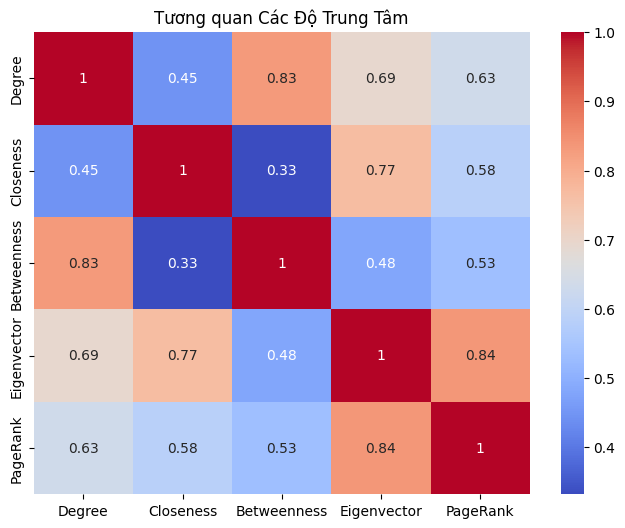

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Tương quan Các Độ Trung Tâm')
plt.show()

In [19]:
# Sắp xếp đỉnh theo bậc (top 10)
top_nodes_degree = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nút theo bậc:")
for node, deg in top_nodes_degree:
    print(f"  {node}: {deg}")


Top 10 nút theo bậc:
  Đinh Phạm Cẩm Ly: 49
  Ngọc My: 37
  Bảoo Bảoo: 34
  Thùy Dương: 32
  Nhật Minhh: 32
  Ngọc Hân: 30
  Vy Vy: 27
  Phạm: 24
  Minh Anh: 23
  Thu Hiền: 23


## Tương đương cấu trúc - Similarity qua degree

In [20]:
# Phân tích tương đương cấu trúc (đơn giản: nhóm nút có degree tương tự) - SỬA LỖI
degrees = [d for n, d in G.degree()]  # Lấy list degrees trực tiếp từ DiDegreeView (tổng in + out)

# Nhóm bằng pd.cut (bins=5 cho 5 nhóm)
degree_groups = pd.cut(degrees, bins=5, labels=['Thấp', 'Thấp-Trung', 'Trung', 'Trung-Cao', 'Cao'])

# Tạo dict equivalence (node -> group)
equivalence = dict(zip(G.nodes(), degree_groups))

print("Nhóm tương đương theo bậc (mẫu 10 nút):")
for i, (node, group) in enumerate(list(equivalence.items())[:10]):
    print(f"  {node}: {group}")

# Thống kê nhóm
group_counts = pd.Series(degree_groups).value_counts().sort_index()
print(f"\nThống kê nhóm:\n{group_counts}")

Nhóm tương đương theo bậc (mẫu 10 nút):
  Đinh Thị Thu Thủy: Thấp
  Thư Huỳnh Nguyễn: Thấp
  Trọng Tâm Nguyễn: Thấp
  Tiểu Linh: Thấp
  Như Ý: Thấp
  Hoàng Nhi: Thấp
  XTV Network: Thấp
  Phương Thanh BùiVan Lang University: Thấp
  Nguyễn Bảo Thiên: Thấp
  Hïghlæñdß BrēēdßFr. Peter's Secondary School, Jiwaka Province (Fatima): Thấp

Thống kê nhóm:
Thấp          115
Thấp-Trung      7
Trung           4
Trung-Cao       5
Cao             1
Name: count, dtype: int64


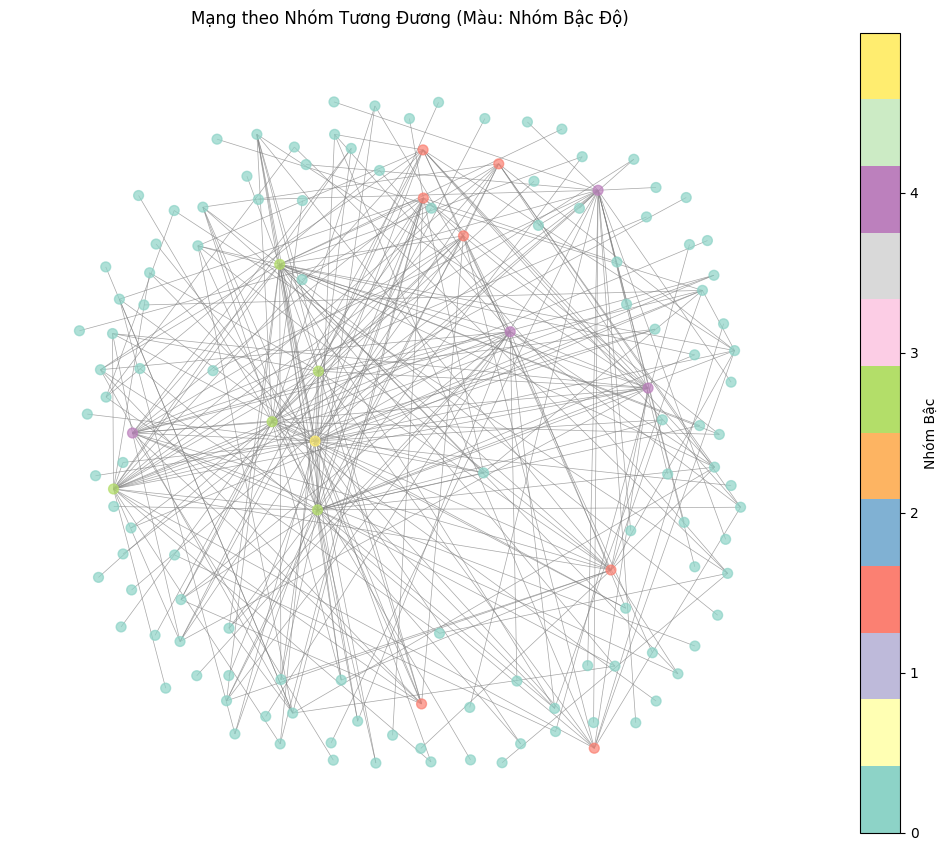

Tổng nodes: 132, Độ trung bình: 5.18


In [21]:
# Visualize: Màu nút theo nhóm (undirected view để vẽ đơn giản)
G_undir = G.to_undirected()  # Chuyển sang undirected để vẽ
pos = nx.spring_layout(G_undir, k=1, iterations=20)
node_colors_eq = [equivalence[n] for n in G_undir.nodes()]

# Map màu cho từng nhóm (categorical)
unique_groups = list(set(node_colors_eq))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_groups)))
color_map = {g: colors[i] for i, g in enumerate(unique_groups)}

plt.figure(figsize=(10, 8))
nx.draw(G_undir, pos, node_color=[color_map[equivalence[n]] for n in G_undir.nodes()], 
        arrows=False, alpha=0.7, node_size=50, edge_color='gray', width=0.5)
plt.title('Mạng theo Nhóm Tương Đương (Màu: Nhóm Bậc Độ)')
sm = plt.cm.ScalarMappable(cmap=plt.cm.Set3, norm=plt.Normalize(vmin=0, vmax=len(unique_groups)))
sm.set_array([])  # Để legend
plt.colorbar(sm, ticks=range(len(unique_groups)), label='Nhóm Bậc')
plt.show()

# Debug info
print(f"Tổng nodes: {len(degrees)}, Độ trung bình: {np.mean(degrees):.2f}")

# Phân tích cộng đồng trong mạng

In [22]:
# K-Core
k_core = nx.core_number(G_undir)
max_core = max(k_core.values())
print(f"Core số cao nhất: {max_core}")
print("Mẫu nút trong core 2+:")
core_nodes = [n for n, c in k_core.items() if c >= 2]
print(f"  {core_nodes[:10]}...")

Core số cao nhất: 6
Mẫu nút trong core 2+:
  ['Thư Huỳnh Nguyễn', 'Trọng Tâm Nguyễn', 'Tiểu Linh', 'Hoàng Nhi', 'Nga Thiên', 'Hà Thị Mỹ Trang', 'Oanh Nguyen', 'Vy Vy', 'Míaa', 'Tuan Baggio']...


In [24]:
!pip install python-louvain

In [26]:
# Louvain (cần community_louvain)
try:
    from community import community_louvain
    partition_louvain = community_louvain.best_partition(G_undir)  # XÓA INDENT Ở ĐÂY
    modularity_louvain = community_louvain.modularity(partition_louvain, G_undir)  # XÓA INDENT
    print(f"Louvain Modularity: {modularity_louvain:.4f}")
    num_communities_louvain = len(set(partition_louvain.values()))
    print(f"Số cộng đồng Louvain: {num_communities_louvain}")
except ImportError:
    partition_louvain = {}  # Placeholder
    modularity_louvain = 0
    num_communities_louvain = 0

Louvain Modularity: 0.4279
Số cộng đồng Louvain: 7


In [29]:
# So sánh: K-Core (số cộng đồng = số core levels), Modularity N/A
num_communities_kcore = len(set(k_core.values()))
print(f"Số cộng đồng K-Core: {num_communities_kcore}")

Số cộng đồng K-Core: 6


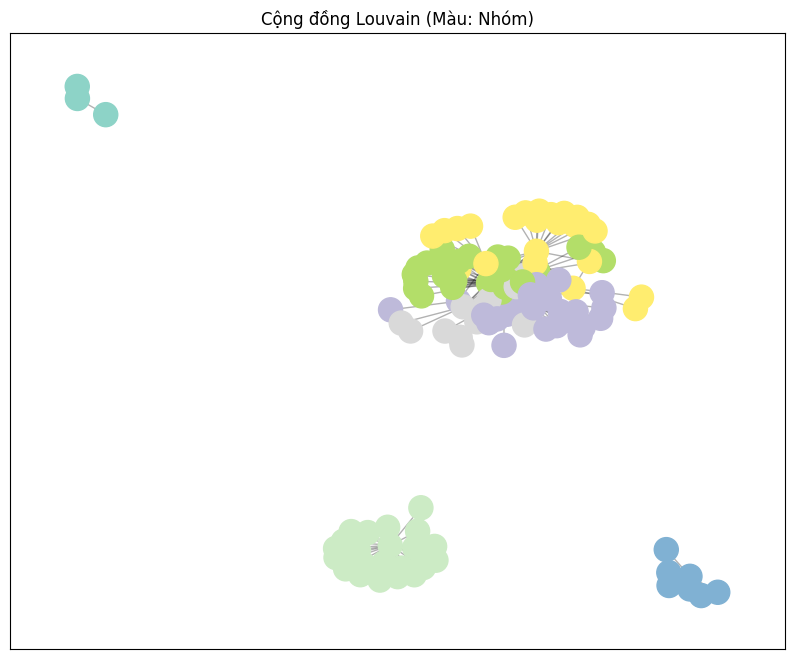

In [28]:
# Visualize cộng đồng Louvain
if partition_louvain:
    pos_com = nx.spring_layout(G_undir)
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(G_undir, pos_com, node_color=list(partition_louvain.values()), cmap=plt.cm.Set3)
    nx.draw_networkx_edges(G_undir, pos_com, alpha=0.3)
    plt.title('Cộng đồng Louvain (Màu: Nhóm)')
    plt.savefig('part4_communities.png')
    plt.show()

In [30]:
# Tóm tắt
summary = f"""
- Mạng có {num_nodes} nút, {num_edges} cạnh, cấu trúc phân cụm {global_clustering:.2f}, đường kính {diameter}.
- Các nút trung tâm (e.g., {top_degree[0][0]}) là bạn bè chính, PageRank nhấn mạnh influencer.
- Cộng đồng: {num_communities_louvain} nhóm (Louvain), phù hợp với bạn chung địa phương.
"""
print(summary)


- Mạng có 132 nút, 342 cạnh, cấu trúc phân cụm 0.13, đường kính Graph không connected (không tính được).
- Các nút trung tâm (e.g., Đinh Phạm Cẩm Ly) là bạn bè chính, PageRank nhấn mạnh influencer.
- Cộng đồng: 7 nhóm (Louvain), phù hợp với bạn chung địa phương.



# KẾT THÚC